In [1]:
# Breast Cancer scRNA-seq Analysis: Triple Negative vs Normal

#Characterizing the tumor microenvironment of Triple Negative Breast Cancer (TNBC) 
#using single-cell RNA sequencing. TNBC is the most aggressive breast cancer subtype — 
#lacking estrogen receptor, progesterone receptor, and HER2 expression, meaning it 
#can't be treated with hormone or targeted therapies. Understanding its transcriptional 
#landscape at single-cell resolution has direct clinical relevance.

#**Dataset:** GSE161529 (GEO) — 13 normal and 8 TNBC tumor samples, 117,232 cells  
#**Processing:** See 01_data_processing.ipynb for full pipeline  
#**Tools:** Scanpy 1.11.5, Python 3.10

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

adata = sc.read('../data/breast_cancer_annotated.h5ad')
print(adata)
print(f"\nCondition counts:")
print(adata.obs['condition'].value_counts())

AnnData object with n_obs × n_vars = 117232 × 2499
    obs: 'sample', 'condition', 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Condition counts:
condition
Tumor_TN    59362
Normal      57870
Name: count, dtype: int64


In [3]:
## Dataset Overview

#After quality control filtering, we retained 117,232 cells across 21 patients — 
#57,870 normal and 59,362 TNBC tumor cells. The dataset is well balanced between 
#conditions, which is important for fair comparison.

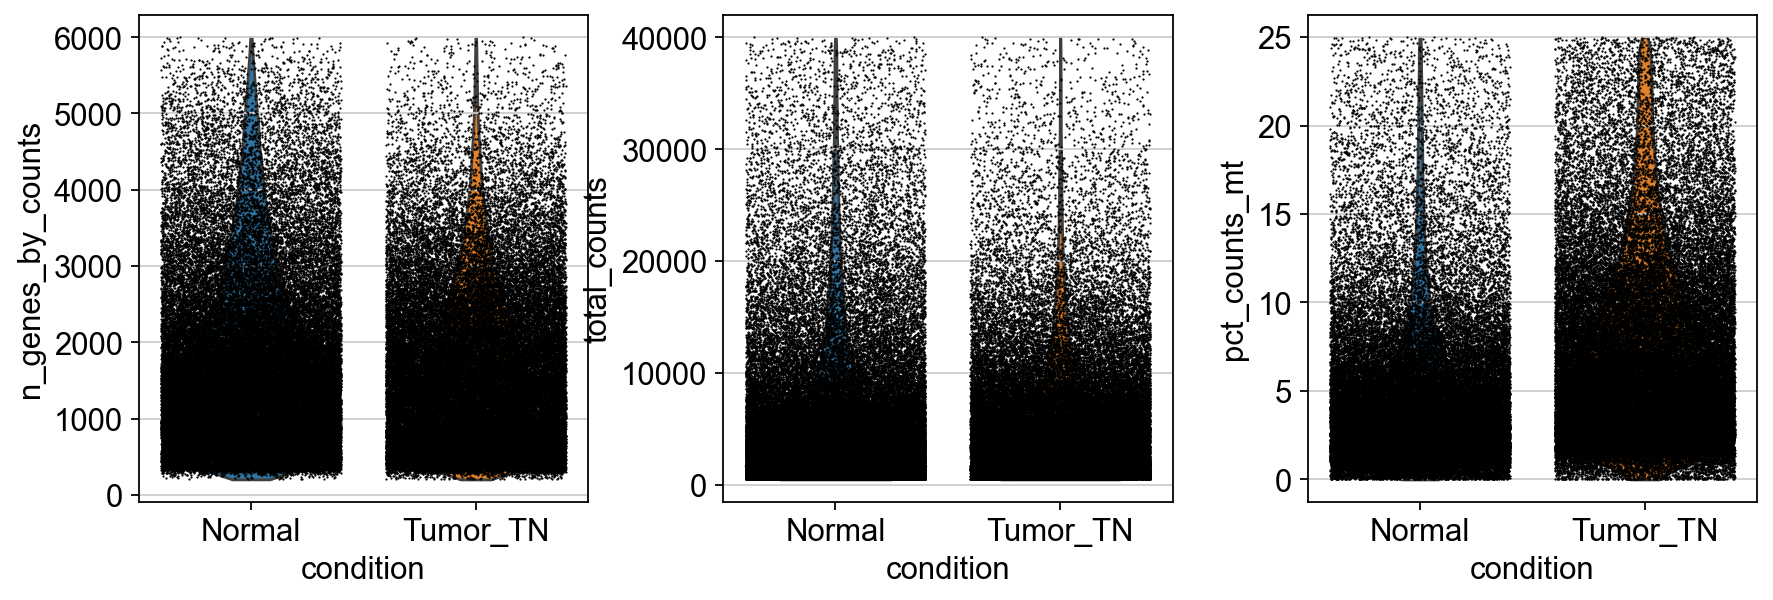

In [4]:
# QC metrics by condition
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='condition',
             save='_qc_metrics.png')

In [5]:
## Dimensionality Reduction and Clustering

#UMAP embedding computed from the top 30 principal components using 15 nearest 
#neighbors. The UMAP reveals clear separation between tumor and normal cells, 
#with distinct clusters visible even before labeling.

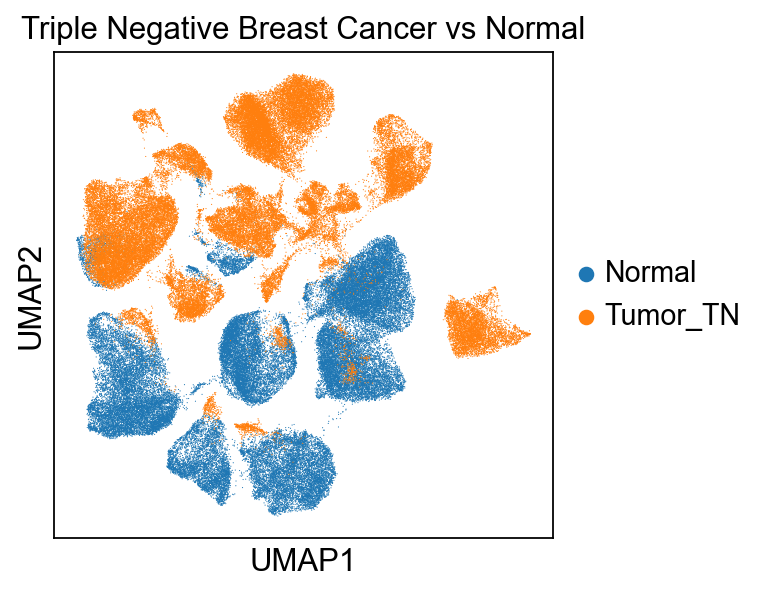

In [6]:
sc.pl.umap(adata, color='condition',
           title='Triple Negative Breast Cancer vs Normal',
           save='_condition.png')

In [7]:
## Cell Type Annotation

#21 cell populations identified using Leiden clustering and annotated by matching 
#marker genes against known cell type signatures. The tumor microenvironment contains 
#a diverse mix of epithelial, immune, stromal, and vascular cell types.

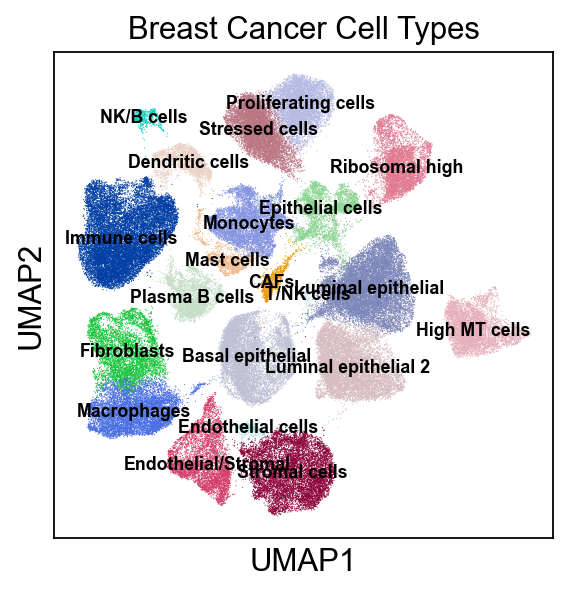

In [8]:
sc.pl.umap(adata, color='cell_type', legend_loc='on data',
           title='Breast Cancer Cell Types', legend_fontsize=8,
           save='_celltypes.png')

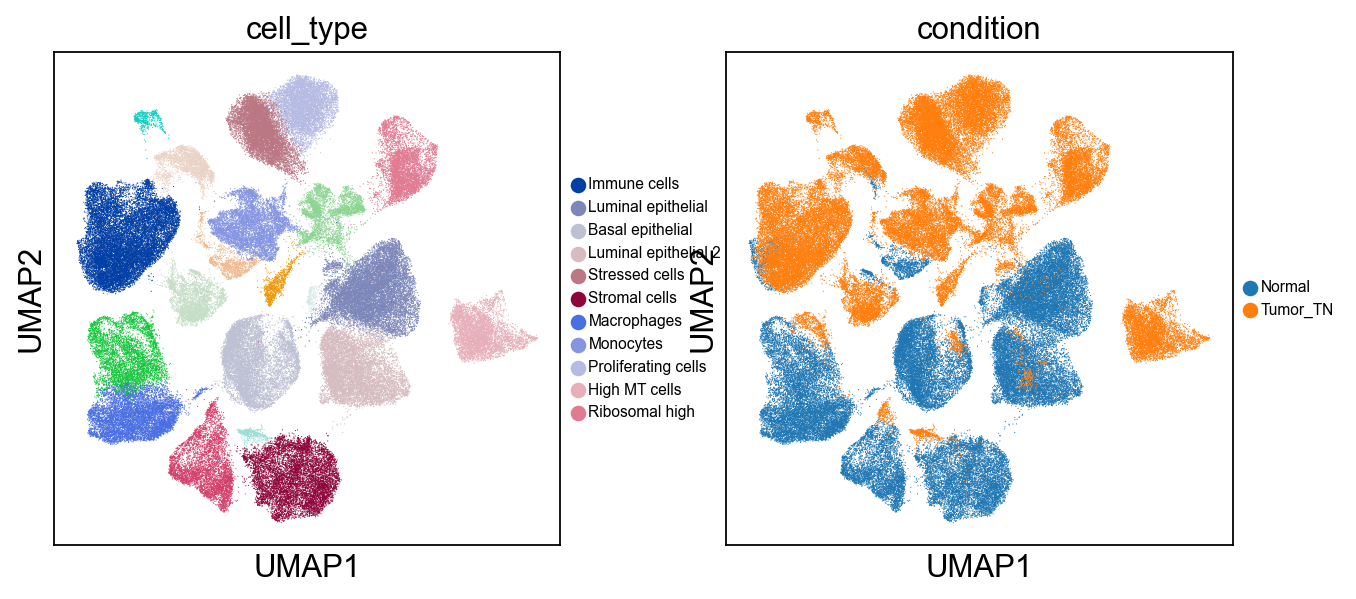

In [9]:
sc.pl.umap(adata, color=['cell_type', 'condition'],
           ncols=2, legend_fontsize=7,
           save='_celltypes_condition.png')

In [10]:
## Marker Gene Expression

#Dot plot showing canonical marker gene expression across cell types. 
#Dot size = fraction of cells expressing the gene, color = mean expression level.

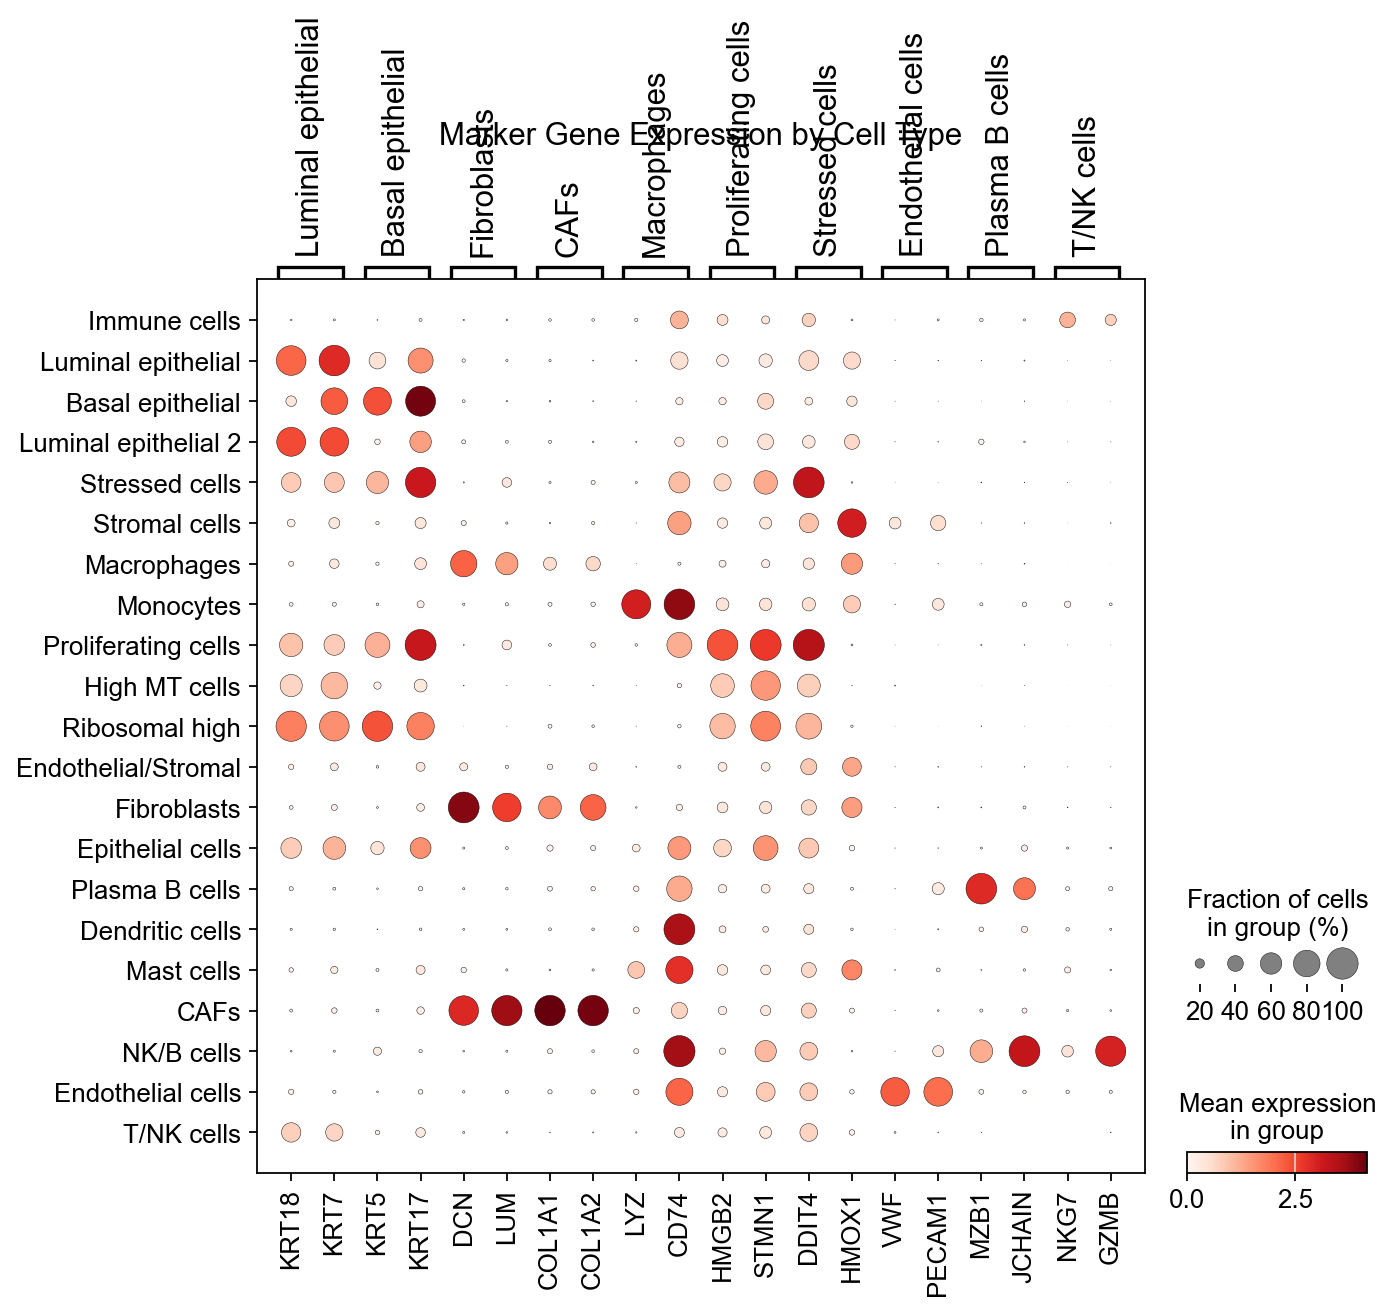

In [11]:
marker_genes = {
    'Luminal epithelial': ['KRT18', 'KRT7'],
    'Basal epithelial': ['KRT5', 'KRT17'],
    'Fibroblasts': ['DCN', 'LUM'],
    'CAFs': ['COL1A1', 'COL1A2'],
    'Macrophages': ['LYZ', 'CD74'],
    'Proliferating cells': ['HMGB2', 'STMN1'],
    'Stressed cells': ['DDIT4', 'HMOX1'],
    'Endothelial cells': ['VWF', 'PECAM1'],
    'Plasma B cells': ['MZB1', 'JCHAIN'],
    'T/NK cells': ['NKG7', 'GZMB']
}

sc.pl.dotplot(adata, marker_genes, groupby='cell_type',
              dendrogram=False,
              title='Marker Gene Expression by Cell Type',
              save='_marker_genes.png')

In [12]:
## Tumor vs Normal Cell Type Composition

#Comparing cell type proportions between conditions reveals the hallmarks of TNBC.

In [13]:
proportions = adata.obs.groupby(['cell_type', 'condition']).size().unstack(fill_value=0)
proportions['total'] = proportions.sum(axis=1)
proportions['pct_tumor'] = (proportions['Tumor_TN'] / proportions['total'] * 100).round(1)
proportions['pct_normal'] = (proportions['Normal'] / proportions['total'] * 100).round(1)

print(proportions[['Normal', 'Tumor_TN', 'pct_normal', 'pct_tumor']].sort_values('pct_tumor', ascending=False))

condition             Normal  Tumor_TN  pct_normal  pct_tumor
cell_type                                                    
Ribosomal high             0      5173         0.0      100.0
NK/B cells                 0       523         0.0      100.0
CAFs                       0       908         0.0      100.0
Stressed cells             0      8333         0.0      100.0
Proliferating cells        0      6271         0.0      100.0
High MT cells              1      5343         0.0      100.0
Monocytes                 54      6278         0.9       99.1
Epithelial cells          53      3615         1.4       98.6
Dendritic cells          108      2331         4.4       95.6
Plasma B cells           224      3126         6.7       93.3
Immune cells            1064     14884         6.7       93.3
Endothelial cells         31       427         6.8       93.2
Fibroblasts             4033       725        84.8       15.2
Mast cells              1137       120        90.5        9.5
Endothel

/var/folders/m0/my66jx5974n5jwyr68bndpg80000gn/T/ipykernel_82642/804749673.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportions = adata.obs.groupby(['cell_type', 'condition']).size().unstack(fill_value=0)


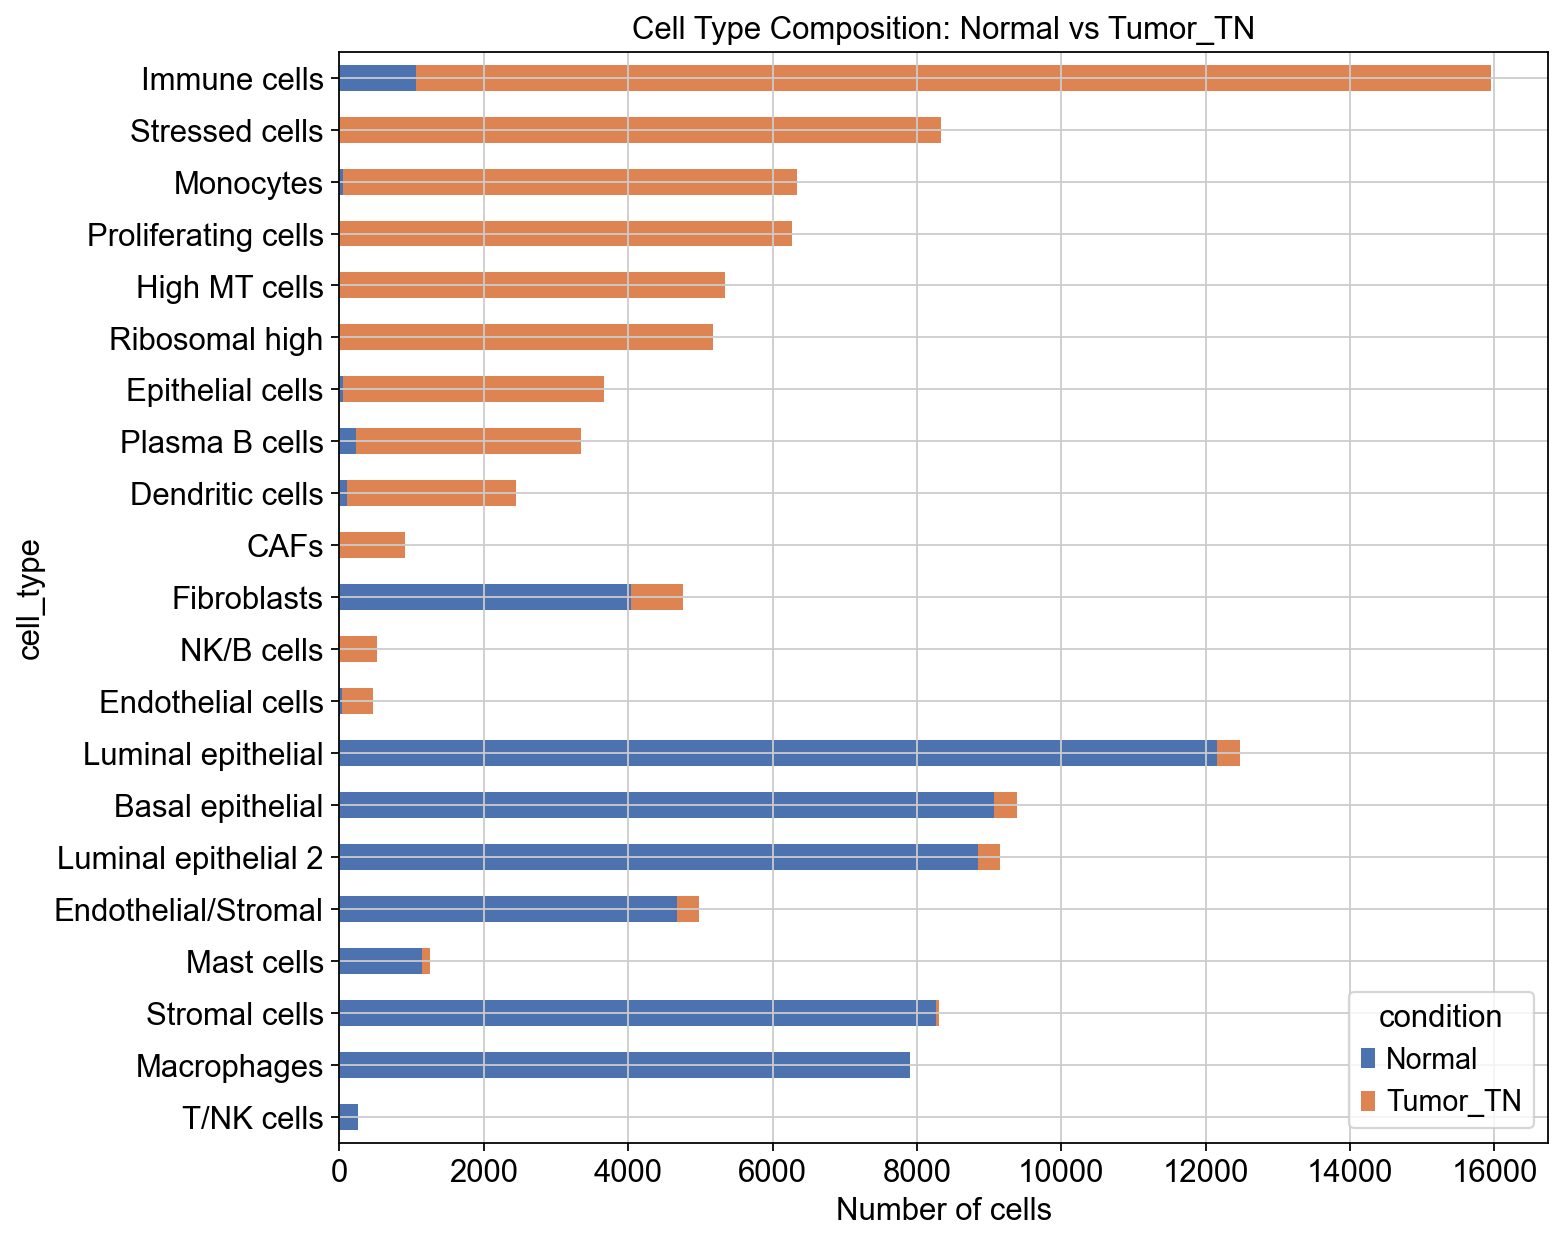

In [14]:
ax = proportions[['Normal', 'Tumor_TN']].sort_values('Tumor_TN').plot(
    kind='barh',
    stacked=True,
    figsize=(10, 8),
    color=['#4C72B0', '#DD8452']
)
plt.title('Cell Type Composition: Normal vs Tumor_TN', fontsize=14)
plt.xlabel('Number of cells')
plt.tight_layout()
plt.savefig('../figures/cell_type_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
## Key Findings

#**Tumor-enriched populations (100% tumor):**
#- **Proliferating cells** (6,271 cells) — active cell division is a hallmark of cancer
#- **Stressed cells** (8,333 cells) — hypoxic and metabolic stress in tumor cores
#- **CAFs** (908 cells) — cancer-associated fibroblasts recruited to remodel the 
#  tumor microenvironment and support tumor growth
#- **High MT cells** — elevated mitochondrial activity reflecting metabolic 
#  reprogramming of cancer cells

#**Normal-enriched populations:**
#- **Luminal and basal epithelial** (~97% normal) — healthy breast tissue architecture 
#  largely replaced in TNBC
#- **Macrophages** (99.8% normal) vs **Monocytes** (99.1% tumor) — a shift in myeloid 
#  cell states between normal and tumor microenvironment

#These findings are consistent with published TNBC literature and reflect the 
#aggressive, metabolically active nature of triple negative breast cancer.